In [27]:
import numpy as np
from scipy import constants
import pandas as pd
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
NA = 0.1
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
#test

# 3 ions, no tweezers, modes as bar chart

In [7]:
N = 3
tweezed_ions = []
w_rf_a = 2*pi*1e6
w_rf_r = 2*pi*3e6
ueq = ion_spacing(N, w_rf_a)[0]
P_opt = 0
w0 = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]

    

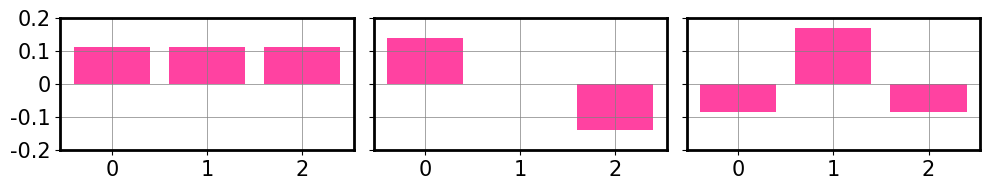

In [8]:
fig, axes = plt.subplots(nrows=1, ncols=N, figsize=(10, 2), dpi=100)  # Adjusted figsize and dpi

# Loop through each mode and plot
for i in range(N):  # Single row for modes 0 to N-1
    ion_numbers = np.arange(0, N)  # Ion indices
    ax = axes[i]  # Get the current axis

    # Plot the eta values for the current mode
    ax.bar(ion_numbers, etas_radial[i], color='#FF42A1')  # Use etas_radial[i] directly for bar heights
    ax.set_ylim(-0.2, 0.2)  # Adjust y-axis limits as needed

    # Set x-ticks for every ion
    ax.set_xticks(ion_numbers)  # Show every ion number
    ax.set_xticklabels(ion_numbers, fontsize=15)  # Set larger font size for x-tick labels

    # Set y-ticks for all plots but only show labels for the leftmost plot
    ax.set_yticks([-0.2, -0.1, 0, 0.1, 0.2])  # Set specific y-tick positions
    if i == 0:
        ax.set_yticklabels([-0.2, -0.1, 0, 0.1, 0.2], fontsize=15)  # Show y-tick labels for the leftmost plot
    else:
        ax.set_yticklabels([])  # Hide y-tick labels for other plots

    # Set thicker axes lines
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(2)

    # Add gridlines
    ax.grid(True, which='both', axis='both', color='gray', linestyle='-', linewidth=0.5)

    # Set tick labels fontsize
    ax.tick_params(axis='both', which='major', labelsize=15)  # Increased tick mark font size

# Use tight layout to adjust spacing
fig.tight_layout()

plt.show()

# 8 circles equally spaced in a line

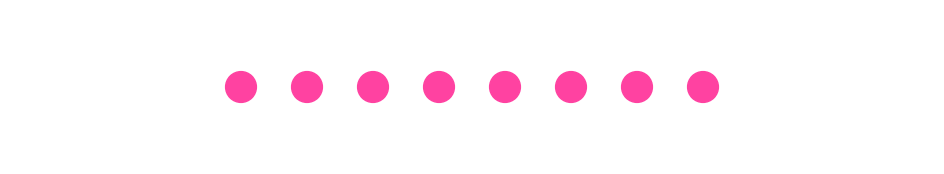

In [9]:
# Number of circles
num_circles = 8

# Circle parameters
radius = 0.1  # Radius of each circle
spacing = 0.5  # Spacing between circles
y_position = 0  # Fixed y-coordinate for all circles

# Calculate the x-coordinates for the circles
x_coords = np.linspace(-1.5, 1.5, num_circles)  # Equally spaced x-coordinates

# Create the plot
fig, ax = plt.subplots(figsize=(20, 2))

# Plot the circles
for x in x_coords:
    circle = plt.Circle((x, y_position), radius, color='#FF42A1', zorder=2)  # Circle with fixed radius
    ax.add_artist(circle)

# Set equal aspect ratio
ax.set_aspect('equal')

# Set limits for better visualization
ax.set_xlim(-3, 3)
ax.set_ylim(-0.5, 0.5)

# Remove axes for a cleaner look
ax.axis('off')

# Show the plot
plt.show()

# modes for 8 ions, no tweeezers yet

In [4]:
N = 8
tweezed_ions = []
w_rf_a = 2*pi*1e6
w_rf_r = 2*pi*4e6
ueq = ion_spacing(N, w_rf_a)[0]
P_opt = 0
w0 = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]

    

In [49]:
print(max(max(etas_radial))+0.01)
print( (-max(max(etas_radial))-0.05+max(max(etas_radial))+0.05)/2 )

0.10660948403102538
0.0


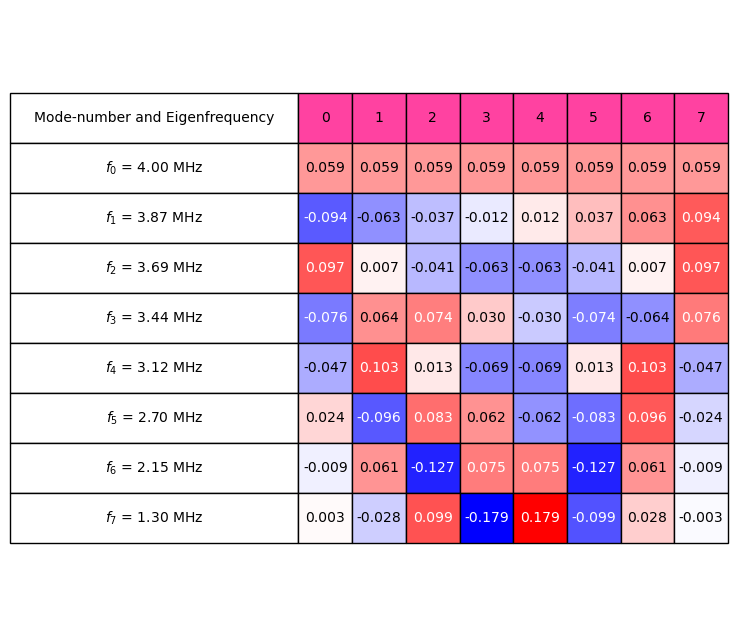

In [66]:
fig, ax = plt.subplots(figsize=(1, 1 * len(radial_modes)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(radial_modes):
    # Convert omega from radians per second to MHz
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.3f}" for eta in etas_radial[index]]  # Use etas_radial for the cell values
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Mode-number and Eigenfrequency'] + [f"{i}" for i in range(len(etas_radial[0]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(etas_radial[0]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-max(max(etas_radial))-0.05, vmax=max(max(etas_radial))+0.05)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.07 < value < 0.07 else 'white')

# Set gray background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('#FF42A1')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white

# Show the plot
plt.show()

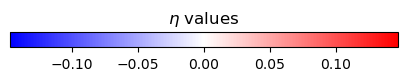

In [69]:
# Create a figure and axis for the color bar
fig, ax = plt.subplots(figsize=(5,0.2))
fig.subplots_adjust(bottom=0.1)
plt.title("$\eta$ values")

# Create a color bar
cbar = mcolorbar.ColorbarBase(ax, cmap=cmap,
                              norm=norm,
                              orientation='horizontal')
# Add y-tick marks at the min and max

cbar.set_label('')
plt.show()